In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import math

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(224),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # these values are for ImageNetDataset
])
transforms

Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [4]:
dataset = torchvision.datasets.ImageFolder('/kaggle/input/stable-imagenet1k/imagenet1k', 
                                           transform=transforms)


In [5]:
loader = DataLoader(dataset, shuffle=True, batch_size=256, num_workers=4)

In [6]:
for img, lab in loader:
    break

In [7]:
x = img.view(img.shape[0], 3, 16, 14, 16, 14)
x = x.permute(0, 2, 4, 1, 3, 5)
x = x.reshape(img.shape[0], 16*16, 3, 14, 14)
x.shape

torch.Size([256, 256, 3, 14, 14])

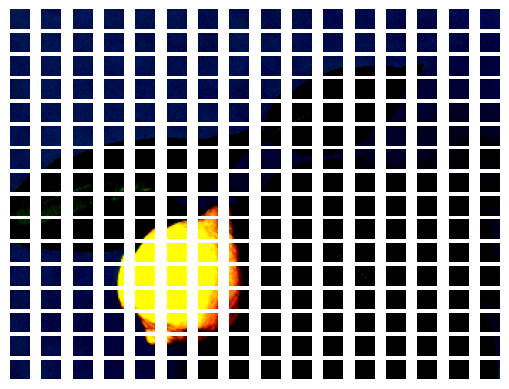

In [8]:
fig, ax = plt.subplots(16,16)
for i in range(16):
    for j in range(16):
        ax[i, j].imshow(x[0, i*16+j, ...].permute(1, 2, 0))
        ax[i, j].axis('off')
plt.show()

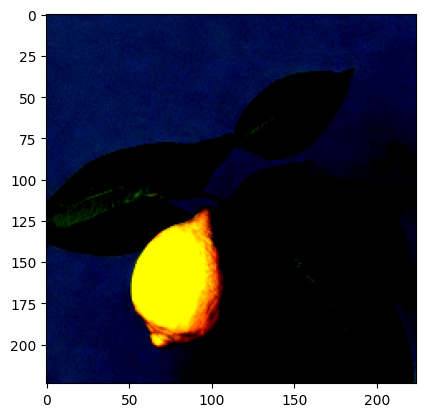

In [9]:
plt.imshow(img[0].permute(1,2,0))

In [ ]:
# You can optionally set a generator for reproducibility
generator = torch.Generator().manual_seed(42)
train_size = int(0.8*len(dataset))
test_size = len(dataset) - train_size
# 3. Perform the split
train_dataset, test_dataset = random_split(
    dataset, 
    [train_size, test_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, shuffle=True, batch_size=64, num_workers=4)
test_loader = DataLoader(test_dataset, shuffle=True, batch_size=64, num_workers=4)

In [11]:
class LinearProjPatchEmbedding(nn.Module):
    def __init__(self, H, W, C, nH, nW, hidden_dim):
        super(LinearProjPatchEmbedding, self).__init__()
        self.H = H
        self.W = W
        self.C = C
        self.nH = nH
        self.nW = nW
        self.hidden_dim = hidden_dim
        self.pH = H // nH
        self.pW = W // nW
        self.proj = nn.Linear(self.pH*self.pW*self.C, self.hidden_dim)
    def forward(self, x):
        """X is image tensor batch of shape (B, C, H, W)"""
        b,c,h,w = x.shape
        x = x.view(b, c, self.nH, self.pH, self.nW, self.pW)
        x = x.permute(0, 2, 4, 1, 3, 5)
        x = x.reshape(b, self.nH*self.nW, c*self.pH*self.pW).contiguous()
        projected = self.proj(x)
        return projected

In [12]:
class MultiHeadAttn(nn.Module):
    def __init__(self, n_head, d_model, d_k=None):
        """n_head = number of head
        d_model = model's hidden state dimension
        d_k = Projection dimension of Q and K"""
        super(MultiHeadAttn, self).__init__()
        self.n_head = n_head
        self.d_model = d_model
        self.d_v = d_model//n_head # d_model for output is splitted to n_heads
        self.d_k = d_k if d_k is not None else self.d_v # usually same as d_v
        self.wq = nn.Linear(d_model, n_head*self.d_k, bias=False)
        self.wk = nn.Linear(d_model, n_head*self.d_k, bias=False)
        self.wv = nn.Linear(n_head*self.d_k, n_head*self.d_v, bias=False)
        self.wo = nn.Linear(n_head*self.d_v, d_model, bias=False)
    def split_heads(self, x):
        B, T, D = x.shape
        d_head = D//self.n_head
        x = x.view(B, T, self.n_head, d_head).transpose(1,2) # this makes (B, n_head, T, d_head)
        return x
    def combine_heads(self, x):
        B, N, T, D = x.shape
        x = x.transpose(1, 2).contiguous()
        x = x.view(B, T, N*D) # B,N,T,D -> B,T,N,D -> B,T,N*D
        return x
    
    def forward(self, Q, K, V):
        Q = self.split_heads(self.wq(Q))
        K = self.split_heads(self.wk(K))
        V = self.split_heads(self.wv(V))

        affinity = F.softmax(torch.matmul(Q, K.transpose(-1, -2)) / (self.d_k**0.5), dim=-1) # B, N, T, T
        mha = affinity @ V # (B, N, T, T)@(B, N, T, D) = (B, N, T, D)
        output = self.wo(self.combine_heads(mha))
        return output

In [13]:
class TransformerLayer(nn.Module):
    def __init__(self, d_model, n_head, mlp_size, dropout = 0.0):
        super(TransformerLayer, self).__init__()
        self.d_model = d_model
        self.n_head = n_head
        self.mlp_size = mlp_size
        self.layer_norm1 = nn.LayerNorm(d_model)
        self.layer_norm2 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttn(n_head, d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, mlp_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_size, d_model),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        norm = self.layer_norm1(x)
        attn_output = self.mha(norm, norm, norm)
        x = attn_output + x

        norm = self.layer_norm2(x)
        projected = self.mlp(norm)
        x = projected + x

        return x

In [14]:
class VisionEncoder(nn.Module):
    def __init__(self, n_layers, d_model, n_head, mlp_size, dropout=0.0):
        super(VisionEncoder, self).__init__()
        self.layers = nn.Sequential(
            *[TransformerLayer(d_model, n_head, mlp_size, dropout)
            for _ in range(n_layers)]
        )
        self.layer_norm = nn.LayerNorm(d_model)
    def forward(self, x):
        x = self.layers(x)
        x = self.layer_norm(x)
        return x

In [15]:
class ViT(nn.Module):
    def __init__(self, img_dims : tuple[int, int, int] = (3, 224, 224), 
                 n_patch : int = 16, n_layers : int = 12, 
                 hidden_dim : int = 1024, n_head : int = 16, 
                 mlp_size : int = 1024, num_classes : int = 1000, dropout : float = 0.0):
        super(ViT, self).__init__()
        self.patch_layer = LinearProjPatchEmbedding(img_dims[1], img_dims[2], img_dims[0], n_patch, n_patch, hidden_dim)
        self.cls_embedding = nn.Parameter(torch.zeros(1,1,hidden_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, n_patch*n_patch + 1,hidden_dim)) # +1 for the cls token with n_patch**2 number of image sequence
        nn.init.trunc_normal_(self.pos_embedding, std=0.02) # trunc_normal_ clips values att +-2*std
        nn.init.trunc_normal_(self.cls_embedding, std=0.02)
        self.transformer = VisionEncoder(n_layers, hidden_dim, n_head, mlp_size, dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        """x is image batch tensor of shape (B, C, H, W)"""
        patches = self.patch_layer(x)
        concated = torch.cat([self.cls_embedding.expand(x.shape[0], -1,-1), patches], dim=1) # becomes (B, n_patches**2+1, hidden_dim)
        x = self.transformer(concated)
        x = self.head(x[:, 0, :]) # B,T,D -> B,C
        return x

In [ ]:
vit_base = ViT(
    img_dims = (3, 224, 224),
    n_patch = 16,
    n_layers = 12,
    hidden_dim = 768,
    n_head = 12,
    mlp_size = 3072,
    num_classes = 1000,
    dropout = 0.0
).to(device)
print(f"Model size: {sum(p.numel() for p in vit_base.parameters() if p.requires_grad)/10**6}M")


# vit_base = ViT(
#     img_dims = (3, 224, 224),
#     n_patch = 16,
#     n_layers = 4,
#     hidden_dim = 256,
#     n_head = 8,
#     mlp_size = 256,
#     num_classes = 1000,
#     dropout = 0.3
# ).to(device)
# print(f"Model size: {sum(p.numel() for p in vit_base.parameters() if p.requires_grad)/10**6}M")

Model size: 2.053864M


In [36]:
# vit_large = ViT(
#     img_dims = (3, 224, 224),
#     n_patch = 16,
#     n_layers = 24,
#     hidden_dim = 1024,
#     n_head = 16,
#     mlp_size = 4096,
#     num_classes = 1000,
#     dropout = 0.0
# ).to(device)
# print(f"Model size: {sum(p.numel() for p in vit_large.parameters() if p.requires_grad)/10**6}M")

In [37]:
# vit_huge = ViT(
#     img_dims = (3, 224, 224),
#     n_patch = 16,
#     n_layers = 32,
#     hidden_dim = 1280,
#     n_head = 16,
#     mlp_size = 5120,
#     num_classes = 1000,
#     dropout = 0.0
# ).to(device)
# print(f"Model size: {sum(p.numel() for p in vit_huge.parameters() if p.requires_grad)/10**6}M")

In [ ]:
base_lr = 2e-4

optimizer = torch.optim.Adam(
    vit_base.parameters(),
    lr=base_lr,
    betas=(0.9, 0.999),
    weight_decay=0.1
)

In [ ]:
warmup_steps = 10_000
total_steps = 1_000_000

def warmup_cosine(step):
    if step < warmup_steps:
        # Linear warmup 0 → base_lr
        return float(step) / float(warmup_steps)
    # Cosine decay 1 → 0
    progress = (step - warmup_steps) / float(total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=warmup_cosine
)
loss_fn = torch.nn.CrossEntropyLoss()

In [40]:
from tqdm import tqdm

In [ ]:
EPOCHS = 50
global_step = 0
for e in range(EPOCHS):
    loss_ = 0
    acc_ = 0
    vit_base.train()
    for i, (img, lab) in enumerate((train_loader)):
        img = img.to(device)
        lab = lab.to(device)

        y_pred = vit_base(img)
        loss = loss_fn(y_pred, lab)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()     # IMPORTANT: call every step
        global_step += 1
        loss_ += loss
        acc_ += (y_pred.argmax(dim=-1).cpu()==lab.cpu()).sum()/img.shape[0]
    print(f"Epoch {e+1}, Train Loss: {round(loss_.item()/len(train_loader), 4)}, Accuracy: {acc_/len(train_loader)}")
    loss_ = 0
    acc_ = 0
    vit_base.eval()
    with torch.no_grad():
        for i, (img, lab) in enumerate((test_loader)):
            img = img.to(device)
            lab = lab.to(device)
    
            y_pred = vit_base(img)
            loss = loss_fn(y_pred, lab)
            loss_ += loss
            acc_ += (y_pred.argmax(dim=-1).cpu()==lab.cpu()).sum()/img.shape[0]
    print(f"Epoch {e+1}, Test Loss: {round(loss_.item()/len(test_loader), 3)}, Accuracy: {acc_/len(train_loader)}")

100%|██████████| 157/157 [04:05<00:00,  1.57s/it]


Epoch 1, Train Loss: 6.9181, Accuracy: 0.0020775278098881245


100%|██████████| 40/40 [01:01<00:00,  1.54s/it]


Epoch 1, Test Loss: 6.789, Accuracy: 0.00070306466659531


100%|██████████| 157/157 [03:58<00:00,  1.52s/it]


...

Epoch 3, Train Loss: 6.6695, Accuracy: 0.006904358975589275


100%|██████████| 40/40 [00:58<00:00,  1.46s/it]


Epoch 3, Test Loss: 6.646, Accuracy: 0.0017416401533409953


  0%|          | 0/157 [00:06<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import json
with open('mapping.json', 'w') as f:
    json.dump(dataset.class_to_idx, f)

In [ ]:
torch.save(vit_base.state_dict(), 'model.pth')

In [ ]:
vit_new = ViT(
    img_dims = (3, 224, 224),
    n_patch = 16,
    n_layers = 8,
    hidden_dim = 256,
    n_head = 8,
    mlp_size = 512,
    num_classes = 1000,
    dropout = 0.3
).to(device)

vit_new.load_state_dict(torch.load('model.pth', weights_only=False))